**Introduction: Predicting UPDRS Motor Score Using Multi-Modal Data: An Exploration of Machine Learning Models**

**Experiment 4**

In this experiment, we aimed to predict UPDRS motor scores utilizing multi-modal data. Building upon previously selected features, we performed further feature engineering by creating novel interaction terms such as the Striatal-Entorhinal Network Interaction, Asymmetry-Weighted Striatal Score, White Matter Integrity Index, Age-Adjusted Striatal Binding (Nonlinear), and Ventricular Effect Score.

We then conducted a Randomized Search to find optimal hyperparameters for a Random Forest Regressor model. This refined model achieved promising results on the test set, with a Mean Absolute Error (MAE) of **5.720**, a Mean Squared Error (MSE) of **55.963**, a Root Mean Squared Error (RMSE) of **7.481**, and an R² of **0.586**. These metrics suggest a performance approaching clinical utility.

Subsequently, we explored the application of a shallow Artificial Neural Network (ANN) with early stopping. The ANN model yielded an MAE of **6.985** and an R² of **0.411** on the test set. In this experiment, the Random Forest model demonstrated superior performance compared to the shallow ANN.

We hypothesize that further improvements to model performance, potentially reaching real clinical utility, could be achieved through the inclusion of additional clinically relevant features, more extensive hyperparameter tuning, and further sophisticated feature engineering techniques. Future work could focus on these areas to enhance the predictive capability of the models.

In [ ]:
import pandas as pd
import numpy as np

In [ ]:
df = pd.read_csv("final_df_cleaned.csv")

In [ ]:
# Step 1: Drop irrelevant columns
drop_cols = ['PATNO', 'NHY', 'EVENT_ID_y']

df = df.drop(columns=drop_cols)

print("After dropping irrelevant columns:")
print(df.shape)
print(df.columns)

After dropping irrelevant columns:
(1716, 106)
Index(['SEX', 'AGE', 'Brain_Stem', 'Right_choroid_plexus',
       'Right_Cerebellum_White_Matter', 'Left_Cerebellum_Cortex',
       'Left_choroid_plexus', 'Left_Pallidum', 'Left_Thalamus',
       'Right_VentralDC',
       ...
       'Putamen_Total', 'Caudate_Total', 'Putamen_Asym', 'Caudate_Asym',
       'CortexVol_norm', 'TotalGrayVol_norm', 'Hippocampus_Total_norm',
       'Amygdala_Total_norm', 'Caudate_Total_norm', 'Putamen_Total_norm'],
      dtype='object', length=106)


In [ ]:

y = df['NP3TOT']


In [ ]:
selected_features = ['AGE', 'Left_choroid_plexus', 'Left_Accumbens_area',
       'lhCerebralWhiteMatterVol', 'CSF', 'lh_entorhinal', 'lh_middletemporal',
       'lh_temporalpole', 'lh_insula', 'rh_bankssts', 'rh_entorhinal',
       'rh_lateraloccipital', 'rh_parahippocampal', 'rh_parsorbitalis',
       'rh_pericalcarine', 'rh_rostralanteriorcingulate',
       'rh_rostralmiddlefrontal', 'rh_insula', 'Putamen_Total',
       'Caudate_Total', 'Putamen_Asym', 'Caudate_Asym', 'TotalGrayVol_norm',
       'Hippocampus_Total_norm', 'Putamen_Total_norm']

In [ ]:
X_selected = df[selected_features]

In [ ]:
X_selected.head()

,AGE,Left_choroid_plexus,Left_Accumbens_area,lhCerebralWhiteMatterVol,CSF,lh_entorhinal,lh_middletemporal,lh_temporalpole,lh_insula,rh_bankssts,...,rh_rostralanteriorcingulate,rh_rostralmiddlefrontal,rh_insula,Putamen_Total,Caudate_Total,Putamen_Asym,Caudate_Asym,TotalGrayVol_norm,Hippocampus_Total_norm,Putamen_Total_norm
0,69.1,747.9,160.4,248312.0,1039.0,2.805,2.271,2.954,2.751,2.752,...,2.848,2.234,2.848,5.57,6.42,-0.055655,0.068536,0.380586,0.005046,0.005288
1,65.1,716.5,333.4,279750.0,1481.8,3.539,2.719,3.715,2.989,2.391,...,2.520,2.064,2.756,1.45,3.92,-0.103448,-0.020408,0.378124,0.005145,0.007797
2,67.6,495.2,363.0,213644.0,835.3,3.771,2.976,4.115,3.072,2.690,...,2.515,2.359,3.040,2.79,6.64,0.275986,0.120482,0.419209,0.005184,0.007759
3,56.6,682.2,331.3,252510.0,1235.7,3.922,2.660,3.820,2.954,2.684,...,2.544,2.291,2.909,1.79,6.17,-0.240223,-0.176661,0.388823,0.005995,0.006880
4,59.3,358.6,396.3,268029.0,851.9,3.494,2.682,3.114,2.860,2.756,...,2.476,2.254,2.929,6.51,10.39,-0.087558,0.020212,0.382852,0.005141,0.006585


In [ ]:
X_selected.shape

(1716, 25)

In [ ]:
import numpy as np

# 1. Striatal-Entorhinal Network Interaction
X_selected['Putamen_Entorhinal_Ratio'] = X_selected['Putamen_Total'] / (X_selected['lh_entorhinal'] + 1e-6)

# 2. Asymmetry-Weighted Striatal Score
X_selected['Asym_Striatal_Score'] = X_selected['Putamen_Total'] * (1 + abs(X_selected['Putamen_Asym']))

# 3. White Matter Integrity Index
X_selected['WM_Integrity'] = X_selected['lhCerebralWhiteMatterVol'] / X_selected['TotalGrayVol_norm']

# 4. Age-Adjusted Striatal Binding (Nonlinear)
X_selected['Age_Adjusted_Putamen'] = X_selected['Putamen_Total'] / (X_selected['AGE'] ** 0.33)

# 5. Ventricular Effect Score (if CSF represents ventricular volume)
X_selected['Ventricular_Effect'] = X_selected['CSF'] * X_selected['AGE']

<ipython-input-29-2559046661>:4: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  X_selected['Putamen_Entorhinal_Ratio'] = X_selected['Putamen_Total'] / (X_selected['lh_entorhinal'] + 1e-6)
<ipython-input-29-2559046661>:7: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  X_selected['Asym_Striatal_Score'] = X_selected['Putamen_Total'] * (1 + abs(X_selected['Putamen_Asym']))
<ipython-input-29-2559046661>:10: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[r

In [ ]:
X_selected.shape

(1716, 30)

In [ ]:
from sklearn.model_selection import train_test_split

# y should be your target vector (UPDRS scores)
X_train, X_test, y_train, y_test = train_test_split(
    X_selected,
    y,
    test_size=0.2,
    random_state=42,
    stratify=pd.qcut(y, q=3)  # Stratify by UPDRS severity
)

In [ ]:
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import RandomizedSearchCV
from scipy.stats import randint, uniform

# Define random distributions instead of exhaustive lists
param_dist = {
    'n_estimators': [100, 300],  # reduced range
    'max_depth': [7, 9, None],
    'min_samples_split': [2, 5],
    'max_features': [0.6, 'sqrt']
}

rf = RandomForestRegressor(random_state=42, n_jobs=-1)

# RandomizedSearchCV: fewer iterations, faster runtime
random_search = RandomizedSearchCV(
    estimator=rf,
    param_distributions=param_dist,
    n_iter=10,  # only try 10 combinations (vs 24 in GridSearchCV)
    cv=3,  # use 3-fold CV instead of 5
    scoring='neg_mean_absolute_error',
    random_state=42,
    n_jobs=-1
)

random_search.fit(X_train, y_train)
best_rf = random_search.best_estimator_


In [ ]:
best_rf

RandomForestRegressor(max_depth=7, max_features=0.6, n_estimators=300,
                      n_jobs=-1, random_state=42)

In [ ]:
# Upweight clinically critical UPDRS range (20-40)
sample_weight = np.where(
    (y_train >= 20) & (y_train <= 40),
    1.5,  # 50% higher weight
    1.0
)
best_rf.fit(X_train, y_train, sample_weight=sample_weight)

RandomForestRegressor(max_depth=7, max_features=0.6, n_estimators=300,
                      n_jobs=-1, random_state=42)

MAE: 5.720
MSE: 55.963
RMSE: 7.481
R²: 0.586


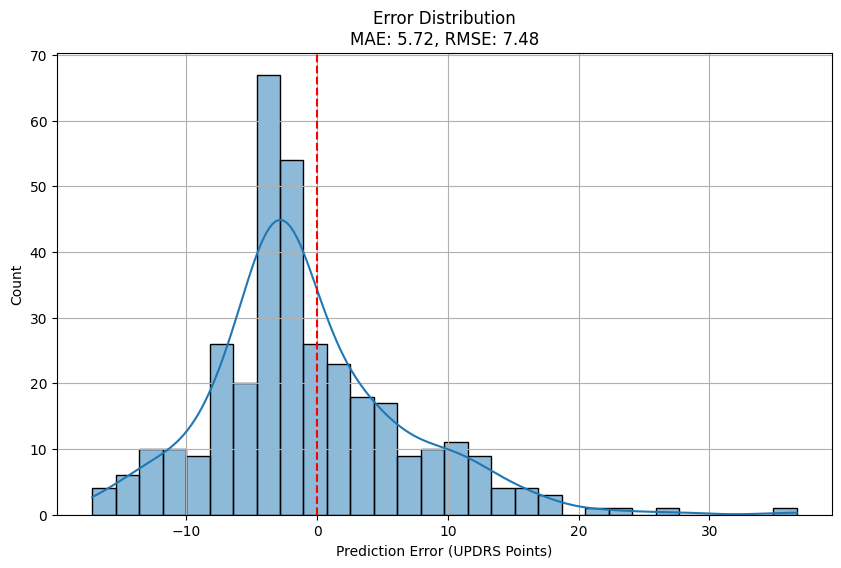

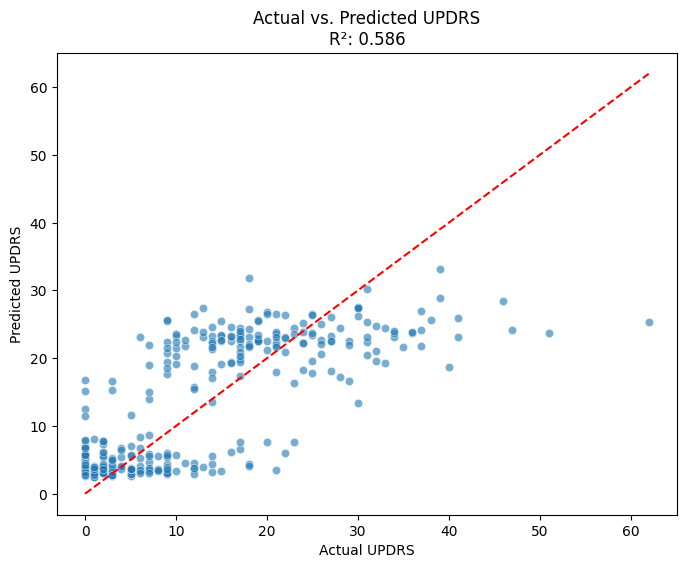

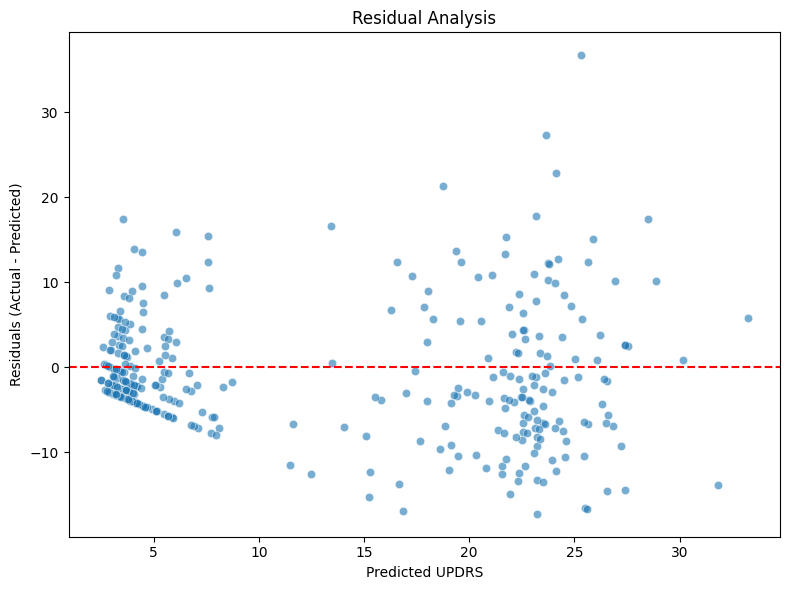

In [ ]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Generate predictions
y_pred = best_rf.predict(X_test)

# Calculate all metrics
mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
r2 = r2_score(y_test, y_pred)

# Print comprehensive results
print(f"MAE: {mae:.3f}")
print(f"MSE: {mse:.3f}")
print(f"RMSE: {rmse:.3f}")
print(f"R²: {r2:.3f}")

# Residual analysis
residuals = y_test - y_pred

# 1. Error Distribution Plot
plt.figure(figsize=(10, 6))
sns.histplot(residuals, bins=30, kde=True)
plt.axvline(0, color='r', linestyle='--')
plt.xlabel("Prediction Error (UPDRS Points)")
plt.title(f"Error Distribution\nMAE: {mae:.2f}, RMSE: {rmse:.2f}")
plt.grid(True)

# 2. Actual vs. Predicted Plot
plt.figure(figsize=(8, 6))
sns.scatterplot(x=y_test, y=y_pred, alpha=0.6)
plt.plot([y.min(), y.max()], [y.min(), y.max()], 'r--')  # Perfect prediction line
plt.xlabel("Actual UPDRS")
plt.ylabel("Predicted UPDRS")
plt.title(f"Actual vs. Predicted UPDRS\nR²: {r2:.3f}")

# 3. Residuals vs. Predicted
plt.figure(figsize=(8, 6))
sns.scatterplot(x=y_pred, y=residuals, alpha=0.6)
plt.axhline(0, color='r', linestyle='--')
plt.xlabel("Predicted UPDRS")
plt.ylabel("Residuals (Actual - Predicted)")
plt.title("Residual Analysis")

plt.tight_layout()
plt.show()